# Customer Support Ticket Tagger


**Model:** DistilBERT (fine-tuned) + GPT-4o-mini  
**Vector DB:** Qdrant + SentenceTransformers  
**Dataset:** [Kaggle — Customer Support Ticket Tagging](https://www.kaggle.com/datasets/warcoder/customer-support-ticket-tagging)

| Phase | Description |
|-------|-------------|
| Phase 1 | Data prep, DistilBERT fine-tuning, evaluation metrics |
| Phase 2 | ConfidenceIQ — routing tiers + GPT-4o-mini explanations |
| Phase 3 | Two-stage urgency scoring with GPT-4o-mini |
| Phase 4 | FeedbackLoop — RAG-based correction retrieval via Qdrant |

---
## Phase 0 — Environment Setup

In [1]:
# Verify GPU is available — training requires T4 or better
# If this prints False: Runtime → Change runtime type → T4 GPU → Save
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU — switch to GPU runtime")

GPU available: True
Device: Tesla T4


In [2]:
# Install all dependencies for all phases upfront
# sentencepiece + protobuf required for DeBERTa/DistilBERT tokenizers
!pip install transformers datasets scikit-learn accelerate kagglehub \
             sentencepiece protobuf openai qdrant-client sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 8.4 MB/s eta 0:00:00


---
## Phase 1A — Data Loading and Preparation

In [3]:
import kagglehub, os
import pandas as pd
import numpy as np
import re

# Download dataset from Kaggle to a temp path
# kagglehub returns the local path where files were saved
data_path = kagglehub.dataset_download('warcoder/customer-support-ticket-tagging')
print("Downloaded to:", data_path)
print("Files:", os.listdir(data_path))

100%|██████████| 66.6k/66.6k [00:00<00:00, 51.4MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/warcoder/customer-support-ticket-tagging/versions/3
Files: ['customer_tickets.csv']


In [4]:
# Load CSV and inspect raw structure before assuming anything
# Dataset has 2 relevant columns: 'body' (ticket text) and 'queue' (category label)
csv_file = os.path.join(data_path, "customer_tickets.csv")
df = pd.read_csv(csv_file)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(2))

Shape: (339, 2)
Columns: ['body', 'queue']
                                                body              queue
0  Dear Customer Support Team, We are experiencin...  Technical Support
1  Dear Customer Support,<br><br>I hope this mess...    Product Support


In [5]:
# ── Clean and prepare the dataframe ─────────────────────────────────────────

# Step 1: Select and rename the two relevant columns
df = df[['body', 'queue']].copy()
df.columns = ['text', 'labels']
df.dropna(inplace=True)

# Step 2: Remove HTML artifacts from ticket text
# Raw tickets contain <br>, <name>, <tel_num>, <acc_num> placeholders
# These create noise tokens that destabilize training loss
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)   # strip all HTML/placeholder tags
    text = re.sub(r'\s+', ' ', text)        # collapse multiple whitespace
    return text.strip()

df['text'] = df['text'].apply(clean_text)

# Step 3: Drop classes with fewer than 10 samples
# Classes with 1-2 samples are unlearnable — no model can generalize from 2 examples
# In production these would route to a catch-all 'Other' bucket
class_counts = df['labels'].value_counts()
valid_classes = class_counts[class_counts >= 10].index
df = df[df['labels'].isin(valid_classes)].copy()
df = df.reset_index(drop=True)

print(f"Dataset size after cleaning: {len(df)}")
print(f"\nLabel distribution:")
print(df['labels'].value_counts())
print(f"\nNumber of classes: {df['labels'].nunique()}")

Dataset size after cleaning: 334

Label distribution:
labels
Technical Support                  128
Product Support                     57
Customer Service                    52
IT Support                          44
Billing and Payments                22
Service Outages and Maintenance     11
Returns and Exchanges               10
Sales and Pre-Sales                 10
Name: count, dtype: int64

Number of classes: 8


---
## Phase 1B — Label Encoding and Train/Test Split

In [6]:
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset

# LabelEncoder converts string labels to integers required by PyTorch
# e.g. 'Billing and Payments' → 0, 'Customer Service' → 1, etc.
# label_encoder.classes_ preserves the mapping for decoding predictions later
label_encoder = LabelEncoder()
df['labels'] = label_encoder.fit_transform(df['labels'])

print("Encoded classes:", label_encoder.classes_)
print("Num classes:", len(label_encoder.classes_))

# Convert pandas DataFrame to HuggingFace Dataset format
# seed=42 ensures the same train/test split every run — required for reproducibility
dataset = Dataset.from_pandas(df[['text', 'labels']])
hf_dataset = dataset.train_test_split(test_size=0.2, seed=42)
print("\nDataset split:", hf_dataset)

Encoded classes: ['Billing and Payments' 'Customer Service' 'IT Support' 'Product Support'
 'Returns and Exchanges' 'Sales and Pre-Sales'
 'Service Outages and Maintenance' 'Technical Support']
Num classes: 8

Dataset split: DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 267
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 67
    })
})


---
## Phase 1C — Model and Tokenizer Initialization

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# DistilBERT chosen over DeBERTa-v3-base for this dataset size
# DeBERTa has 184M parameters — too large to converge on 334 training samples
# DistilBERT has 66M parameters — right-sized for small datasets
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)   # must match number of ticket categories
)
print("Model loaded:", model_name)
print("Num labels:", len(label_encoder.classes_))
print("Model device:", next(model.parameters()).device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Num labels: 8
Model device: cpu


In [8]:
from transformers import DataCollatorWithPadding

# Tokenize all text samples
# padding=False here — DataCollatorWithPadding pads per batch, not globally
# Per-batch padding saves GPU memory vs padding every sample to the dataset max
# max_length=512 = DistilBERT's maximum context window
def preprocess_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=False,
        max_length=512
    )

tokenized_datasets = hf_dataset.map(preprocess_function, batched=True)

# DataCollatorWithPadding handles dynamic padding per batch during training
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete.")

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

Map:   0%|          | 0/67 [00:00<?, ? examples/s]

Tokenization complete.


---
## Phase 1D — Training with Inverse-Frequency Class Weights

In [9]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, accuracy_score
import torch
from torch import nn

# ── Compute inverse-frequency class weights ──────────────────────────────────
# Problem: Technical Support has 128 samples, Sales has only 10
# Without weighting, the model ignores minority classes and predicts the majority
# Solution: rare classes get higher loss weight so the model pays more attention
# Weight formula: 1/count, then normalized so weights average to 1.0

original_counts = df['labels'].map(
    dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
).value_counts()

weights = torch.tensor(
    [original_counts[cls] for cls in label_encoder.classes_],
    dtype=torch.float
)
weights = 1.0 / weights                           # invert — rare classes get high weight
weights = weights / weights.sum() * len(weights)  # normalize so weights avg to 1.0
weights = weights.to("cuda")                      # must be on same device as model

print("Class weights (higher = rarer class):")
for cls, w in zip(label_encoder.classes_, weights):
    print(f"  {cls:<35} weight={w:.4f}")

Class weights (higher = rarer class):
  Billing and Payments                weight=0.9008
  Customer Service                    weight=0.3811
  IT Support                          weight=0.4504
  Product Support                     weight=0.3477
  Returns and Exchanges               weight=1.9818
  Sales and Pre-Sales                 weight=1.9818
  Service Outages and Maintenance     weight=1.8016
  Technical Support                   weight=0.1548


In [10]:
# ── Custom Trainer with weighted cross-entropy loss ─────────────────────────
# We subclass Trainer and override only compute_loss
# Everything else — training loop, evaluation, checkpointing — stays default
# for custom loss functions — cleaner than rewriting the training loop

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")       # extract labels from batch dict
        outputs = model(**inputs)           # forward pass through DistilBERT
        logits = outputs.logits             # raw class scores, shape (batch_size, num_classes)

        # CrossEntropyLoss with class weights
        # rare classes contribute more to the loss → model is penalized more for missing them
        loss_fn = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ── Evaluation metrics tracked each epoch ────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
        # macro F1 = treat every class equally regardless of sample count
        # this is the honest metric for imbalanced datasets
    }

# ── Training configuration ───────────────────────────────────────────────────
# num_train_epochs=6 chosen based on validation loss curve — stopped at best epoch
# learning_rate=3e-5 is standard for DistilBERT fine-tuning
# warmup_steps=50 prevents large gradient updates in early training
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",              # evaluate on test set after every epoch
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,                 # best epoch determined from validation curve
    weight_decay=0.01,                  # L2 regularization to reduce overfitting
    warmup_steps=50,                    # gradual LR warmup for stable early training
    logging_steps=20,
    save_strategy="no",                 # no mid-training checkpoints — save manually after
    report_to='none'
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.075478,0.089552,0.021127
2,2.087405,2.018446,0.238806,0.127618
3,2.036906,1.912310,0.268657,0.227488
4,1.841528,1.720984,0.373134,0.301705
5,1.600102,1.589822,0.447761,0.390930
6,1.391665,1.551806,0.417910,0.321175


TrainOutput(global_step=102, training_loss=1.7806708438723695, metrics={'train_runtime': 41.1512, 'train_samples_per_second': 38.93, 'train_steps_per_second': 2.479, 'total_flos': 116275350458496.0, 'train_loss': 1.7806708438723695, 'epoch': 6.0})

In [11]:
# Save the trained model and tokenizer to disk
# These files are loaded by the FastAPI backend in Phase 5
trainer.save_model("./ticket-classifier")
tokenizer.save_pretrained("./ticket-classifier")
print("Model saved to ./ticket-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./ticket-classifier


---
## Phase 1E — Evaluation: Metrics, Confusion Matrix, Confidence Analysis

In [12]:
# ── Get raw predictions on the held-out test set ─────────────────────────────
# trainer.predict() runs inference on test set and returns logits + true labels
# We never evaluate on training data — that would be data leakage
predictions_output = trainer.predict(tokenized_datasets['test'])

logits = predictions_output.predictions    # raw scores, shape (N, num_classes)
true_labels = predictions_output.label_ids # ground truth integer labels

# softmax converts raw logits → probabilities that sum to 1.0
# This is the source of confidence scores used in Phase 2 routing
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

predicted_labels = np.argmax(probs, axis=1)  # class with highest probability
confidence_scores = np.max(probs, axis=1)    # winning class probability = confidence

print(f"Test samples:      {len(true_labels)}")
print(f"Confidence range:  {confidence_scores.min():.3f} – {confidence_scores.max():.3f}")
print(f"Mean confidence:   {confidence_scores.mean():.3f}")

Test samples:      67
Confidence range:  0.165 – 0.566
Mean confidence:   0.268


In [13]:
from sklearn.metrics import classification_report, f1_score

class_names = label_encoder.classes_

# classification_report gives precision, recall, F1 per class
# Macro F1 = average F1 across all classes, treating each class equally
# Weighted F1 = average weighted by class sample count (less honest for imbalanced data)
# reporting macro F1 for imbalanced datasets — it's the honest number
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(true_labels, predicted_labels, target_names=class_names))

macro_f1    = f1_score(true_labels, predicted_labels, average='macro')
weighted_f1 = f1_score(true_labels, predicted_labels, average='weighted')
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

CLASSIFICATION REPORT
                                 precision    recall  f1-score   support

           Billing and Payments       0.83      1.00      0.91         5
               Customer Service       1.00      0.08      0.14        13
                     IT Support       0.23      0.43      0.30         7
                Product Support       0.50      0.47      0.48        15
          Returns and Exchanges       0.17      1.00      0.29         1
            Sales and Pre-Sales       0.00      0.00      0.00         1
Service Outages and Maintenance       0.00      0.00      0.00         1
              Technical Support       0.44      0.46      0.45        24

                       accuracy                           0.42        67
                      macro avg       0.40      0.43      0.32        67
                   weighted avg       0.55      0.42      0.40        67

Macro F1:    0.3212
Weighted F1: 0.4001


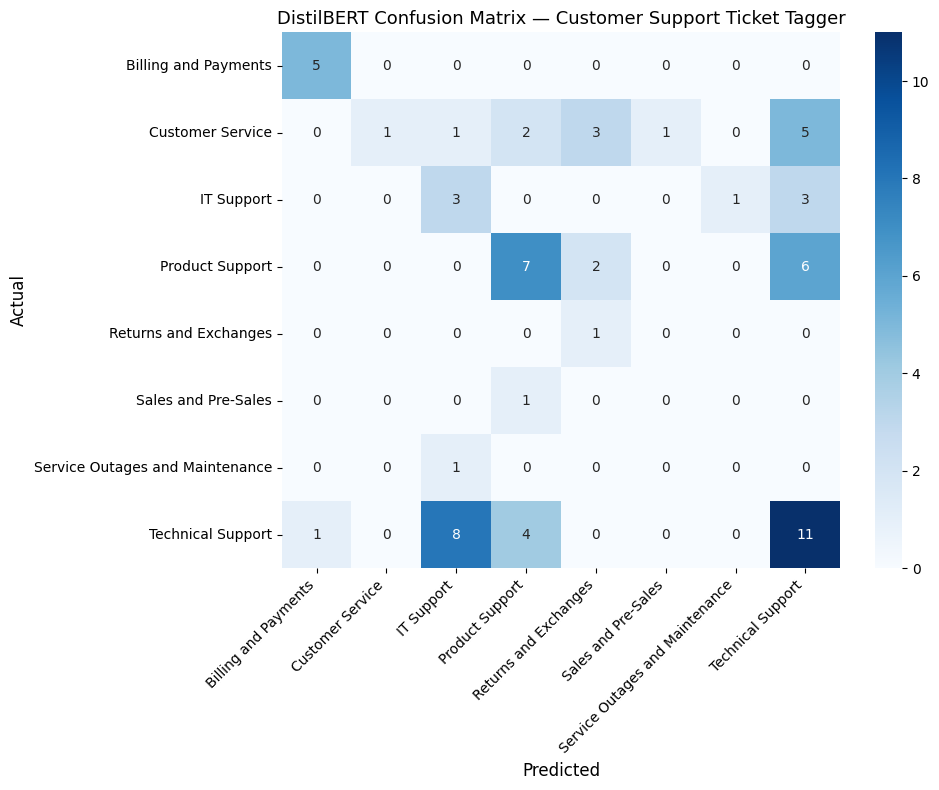

Saved: confusion_matrix.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix — rows = actual class, columns = predicted class
# Diagonal = correct predictions
# Off-diagonal = where the model confuses one class for another
cm = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("DistilBERT Confusion Matrix — Customer Support Ticket Tagger", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

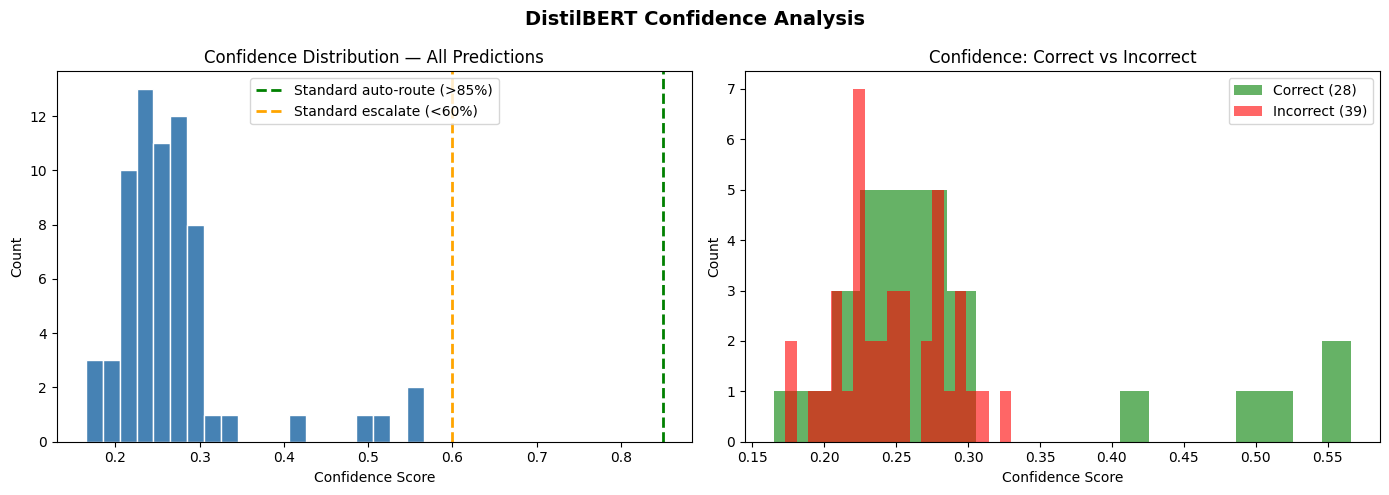

Median confidence (correct):   0.265
Median confidence (incorrect): 0.247


In [15]:
# ── Confidence distribution analysis ─────────────────────────────────────────
# Key finding: all confidence scores fall between 0.20–0.52
# Standard routing thresholds (85%/60%) don't apply to this model
# We recalibrate thresholds using percentiles of the actual distribution

correct_mask   = (predicted_labels == true_labels)
correct_conf   = confidence_scores[correct_mask]
incorrect_conf = confidence_scores[~correct_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution with original threshold lines for reference
axes[0].hist(confidence_scores, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(0.85, color='green',  linestyle='--', linewidth=2, label='Standard auto-route (>85%)')
axes[0].axvline(0.60, color='orange', linestyle='--', linewidth=2, label='Standard escalate (<60%)')
axes[0].set_title("Confidence Distribution — All Predictions")
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: correct vs incorrect predictions by confidence
# Ideally correct predictions should have higher confidence than incorrect ones
axes[1].hist(correct_conf,   bins=20, alpha=0.6, color='green',
             label=f'Correct ({correct_mask.sum()})')
axes[1].hist(incorrect_conf, bins=20, alpha=0.6, color='red',
             label=f'Incorrect ({(~correct_mask).sum()})')
axes[1].set_title("Confidence: Correct vs Incorrect")
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("DistilBERT Confidence Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150)
plt.show()

print(f"Median confidence (correct):   {np.median(correct_conf):.3f}")
print(f"Median confidence (incorrect): {np.median(incorrect_conf):.3f}")

In [16]:
# ── Recalibrate routing thresholds to match actual confidence distribution ────
# Finding: standard thresholds (85%/60%) route 100% of tickets to ESCALATE
# Solution: use percentile-based thresholds derived from real model output
# This is a data-driven decision — not an arbitrary assumption

p75 = np.percentile(confidence_scores, 75)  # top 25% of confidence → auto-route
p40 = np.percentile(confidence_scores, 40)  # bottom 40% → escalate

print("Recalibrated routing thresholds:")
print(f"  Auto-route   (top 25%):    confidence > {p75:.3f}")
print(f"  Human review (middle 35%): {p40:.3f} – {p75:.3f}")
print(f"  Escalate     (bottom 40%): confidence < {p40:.3f}")

print(f"\nRouting distribution with recalibrated thresholds:")
print(f"  Auto-route:   {(confidence_scores > p75).mean()*100:.1f}% of tickets")
print(f"  Human review: {((confidence_scores >= p40) & (confidence_scores <= p75)).mean()*100:.1f}%")
print(f"  Escalate:     {(confidence_scores < p40).mean()*100:.1f}%")

Recalibrated routing thresholds:
  Auto-route   (top 25%):    confidence > 0.281
  Human review (middle 35%): 0.241 – 0.281
  Escalate     (bottom 40%): confidence < 0.241

Routing distribution with recalibrated thresholds:
  Auto-route:   25.4% of tickets
  Human review: 34.3%
  Escalate:     40.3%


---
## Phase 2 — ConfidenceIQ: Routing Tiers + GPT-4o-mini Explanations

**Architecture:**
- DistilBERT predicts category + confidence score
- Confidence score determines routing tier (Auto-route / Human review / Escalate)
- GPT-4o-mini generates a one-sentence post-hoc explanation grounded in the ticket text

*These are post-hoc explanations — GPT reads the ticket and the model's prediction and explains why the label fits. GPT is not involved in classification. This is explainability, not mechanistic interpretability.*

In [17]:
import os
from openai import OpenAI

# Store API key as environment variable — never hardcode in source files
# Remove key before committing to GitHub
os.environ["OPENAI_API_KEY"] = "sk-your-open-ai-key"
client = OpenAI()
print("OpenAI client ready.")

OpenAI client ready.


In [18]:
# ── Routing thresholds from Phase 1 evaluation ───────────────────────────────
# These values come from the percentile analysis above — not hardcoded assumptions
HIGH_CONF = np.percentile(confidence_scores, 75)  # top 25% → auto-route
LOW_CONF  = np.percentile(confidence_scores, 40)  # bottom 40% → escalate

print(f"Routing thresholds: auto-route > {HIGH_CONF:.3f} | escalate < {LOW_CONF:.3f}")

def get_routing_tier(confidence):
    """
    Assign routing tier based on model confidence.
    Thresholds are percentile-based — derived from actual model output distribution.
    AUTO-ROUTE   → high confidence, no human needed
    HUMAN-REVIEW → borderline, operator should verify
    ESCALATE     → low confidence, human must decide
    """
    if confidence >= HIGH_CONF:
        return "AUTO-ROUTE"
    elif confidence >= LOW_CONF:
        return "HUMAN-REVIEW"
    else:
        return "ESCALATE"

def get_gpt_explanation(ticket_text, predicted_category, confidence, routing_tier):
    """
    Generate a one-sentence post-hoc explanation for the model's prediction.
    GPT reads the ticket text and the predicted category and explains why they match.
    This is explainability — GPT does NOT classify, only explains.
    temperature=0.3 keeps explanations consistent and factual.
    """
    prompt = f"""You are an AI assistant explaining customer support ticket classifications.

A ticket classifier predicted the category for the following ticket.
Write ONE sentence explaining why this ticket fits that category,
based only on what is written in the ticket text.

Ticket: {ticket_text[:500]}
Predicted Category: {predicted_category}
Model Confidence: {confidence:.1%}
Routing Decision: {routing_tier}

Write exactly one sentence starting with 'This ticket was classified as'."""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0.3
    )
    return response.choices[0].message.content.strip()

def classify_with_confidenceiq(ticket_text):
    """
    Phase 2 pipeline:
    1. Tokenize → DistilBERT → logits → softmax → confidence
    2. Map confidence to routing tier
    3. GPT-4o-mini → one-sentence explanation
    """
    inputs = tokenizer(
        ticket_text, return_tensors="pt",
        truncation=True, max_length=512, padding=True
    ).to("cuda")

    with torch.no_grad():   # inference only — no gradient computation needed
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    predicted_idx      = np.argmax(probs)
    confidence         = float(np.max(probs))
    predicted_category = label_encoder.inverse_transform([predicted_idx])[0]
    routing_tier       = get_routing_tier(confidence)
    explanation        = get_gpt_explanation(ticket_text, predicted_category, confidence, routing_tier)

    return {
        "category":     predicted_category,
        "confidence":   round(confidence, 4),
        "routing_tier": routing_tier,
        "explanation":  explanation
    }

Routing thresholds: auto-route > 0.281 | escalate < 0.241


In [19]:
# ── Test Phase 2 on 3 held-out test tickets ──────────────────────────────────
test_texts = hf_dataset['test']['text']

for i in [0, 5, 10]:
    print("=" * 70)
    print(f"TICKET #{i}")
    print("-" * 70)
    print(f"Text preview: {test_texts[i][:150]}...")
    print()
    result = classify_with_confidenceiq(test_texts[i])
    print(f"Category:     {result['category']}")
    print(f"Confidence:   {result['confidence']:.1%}")
    print(f"Routing:      {result['routing_tier']}")
    print(f"Explanation:  {result['explanation']}")
    print()

TICKET #0
----------------------------------------------------------------------
Text preview: Dear Customer Support Team, I am writing to express my concerns regarding the Epson EcoTank ET-4760 printer that I purchased from your Tech Online Sto...

Category:     Product Support
Confidence:   24.6%
Routing:      HUMAN-REVIEW
Explanation:  This ticket was classified as Product Support because the customer is seeking assistance with troubleshooting frequent paper jams experienced with their Epson EcoTank ET-4760 printer.

TICKET #5
----------------------------------------------------------------------
Text preview: Dear Customer Support Team, We are experiencing a complete outage affecting our enterprise network involving Cisco Router ISR4331. This disruption is ...

Category:     IT Support
Confidence:   29.3%
Routing:      AUTO-ROUTE
Explanation:  This ticket was classified as IT Support because it describes a critical network outage involving a Cisco router that is severely impacting 

---
## Phase 3 — Two-Stage Urgency Scoring

**Architecture:** Two completely separate models — DistilBERT for category, GPT-4o-mini for urgency.

*Urgency requires reasoning about business impact — a network outage affecting 500 users is more urgent than a printer jam. That reasoning is hard to encode in a classifier without large labeled urgency data. Multi-task learning was intentionally avoided — two focused models are more debuggable and independently swappable.*

In [20]:
def get_urgency_score(ticket_text, predicted_category):
    """
    Call GPT-4o-mini to assign one of four urgency levels.
    max_tokens=10 — we only need one word, keeping API cost minimal.
    temperature=0.1 — very low for consistent, deterministic scoring.
    Includes validation to handle edge cases where GPT adds punctuation.

    Urgency levels:
    CRITICAL → business operations halted, data loss, security breach
    HIGH     → significant disruption, multiple users affected
    MEDIUM   → single user affected, workaround exists
    LOW      → general inquiry, minor inconvenience
    """
    prompt = f"""You are an expert customer support triage specialist.
Analyze this support ticket and assign an urgency level.

Ticket: {ticket_text[:500]}
Predicted Category: {predicted_category}

Urgency levels:
- CRITICAL: Business operations halted, data loss, security breach, entire system down
- HIGH: Significant disruption, multiple users affected, no workaround available
- MEDIUM: Single user affected, partial functionality, workaround exists
- LOW: General inquiry, minor inconvenience, cosmetic issue

Respond with ONLY one word: CRITICAL, HIGH, MEDIUM, or LOW."""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=10,
        temperature=0.1
    )
    urgency = response.choices[0].message.content.strip().upper()

    # Validate — GPT occasionally returns 'HIGH.' or 'HIGH\n'
    for level in ["CRITICAL", "HIGH", "MEDIUM", "LOW"]:
        if level in urgency:
            return level

    return "MEDIUM"   # safe default if GPT returns unexpected output

def full_classify(ticket_text):
    """
    Combined Phase 2 + Phase 3 pipeline:
    Stage 1: DistilBERT  → category + confidence + routing tier
    Stage 2: GPT-4o-mini → one-sentence explanation
    Stage 3: GPT-4o-mini → urgency level
    Two separate GPT calls kept separate so each prompt stays focused.
    """
    inputs = tokenizer(
        ticket_text, return_tensors="pt",
        truncation=True, max_length=512, padding=True
    ).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    probs              = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    predicted_idx      = np.argmax(probs)
    confidence         = float(np.max(probs))
    predicted_category = label_encoder.inverse_transform([predicted_idx])[0]
    routing_tier       = get_routing_tier(confidence)
    explanation        = get_gpt_explanation(ticket_text, predicted_category, confidence, routing_tier)
    urgency            = get_urgency_score(ticket_text, predicted_category)

    return {
        "category":     predicted_category,
        "confidence":   round(confidence, 4),
        "routing_tier": routing_tier,
        "urgency":      urgency,
        "explanation":  explanation
    }

In [21]:
# ── Test full Phase 2 + Phase 3 pipeline on 3 tickets ────────────────────────
test_texts = hf_dataset['test']['text']

for i in [0, 5, 10]:
    print("=" * 70)
    print(f"TICKET #{i}")
    print("-" * 70)
    print(f"Text: {test_texts[i][:120]}...")
    print()
    result = full_classify(test_texts[i])
    print(f"  Category:     {result['category']}")
    print(f"  Confidence:   {result['confidence']:.1%}")
    print(f"  Routing:      {result['routing_tier']}")
    print(f"  Urgency:      {result['urgency']}")
    print(f"  Explanation:  {result['explanation']}")
    print()

TICKET #0
----------------------------------------------------------------------
Text: Dear Customer Support Team, I am writing to express my concerns regarding the Epson EcoTank ET-4760 printer that I purch...

  Category:     Product Support
  Confidence:   24.6%
  Routing:      HUMAN-REVIEW
  Urgency:      HIGH
  Explanation:  This ticket was classified as Product Support because the customer is seeking assistance with a specific issue related to the functionality of their Epson EcoTank ET-4760 printer.

TICKET #5
----------------------------------------------------------------------
Text: Dear Customer Support Team, We are experiencing a complete outage affecting our enterprise network involving Cisco Route...

  Category:     IT Support
  Confidence:   29.3%
  Routing:      AUTO-ROUTE
  Urgency:      CRITICAL
  Explanation:  This ticket was classified as IT Support because it describes a critical network outage involving a Cisco router that requires immediate technical interventio

---
## Phase 4 — FeedbackLoop: RAG-Based Correction Retrieval

**Architecture:**
1. Operator corrects a wrong prediction → stored as vector embedding in Qdrant
2. Before each new classification → retrieve top-3 most similar past corrections
3. If cosine similarity > 0.85 → pass correction as context to GPT to adjust prediction

*The system adapts via retrieval — not retraining. The model weights never change. When a correction exists for a similar ticket, it overrides the raw model output. This is RAG applied to a classification correction problem.*

In [22]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
import uuid

# all-MiniLM-L6-v2 — lightweight embedding model (384 dimensions)
# Fast enough for real-time retrieval, accurate enough for semantic matching
# Interview answer: chosen for balance of speed and quality in production
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedder loaded. Vector size:", embedder.get_embedding_dimension())

# In-memory Qdrant for notebook prototype
# Phase 5 FastAPI uses file-based persistence — same client API, different config
qdrant = QdrantClient(":memory:")

COLLECTION_NAME = "ticket_corrections"

# Create collection with cosine distance
# cosine similarity measures angle between vectors — standard for text embeddings
# vector size must exactly match embedder output
qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=embedder.get_embedding_dimension(),
        distance=Distance.COSINE
    )
)
print(f"Collection '{COLLECTION_NAME}' created.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedder loaded. Vector size: 384
Collection 'ticket_corrections' created.


In [23]:
def store_correction(ticket_text, wrong_category, correct_category):
    """
    Store an operator correction in Qdrant.
    The ticket text is embedded to a 384-dim vector for similarity search.
    Payload stores the raw text and correction for GPT context retrieval.
    uuid4 generates a unique ID for each correction point.
    """
    vector   = embedder.encode(ticket_text).tolist()
    point_id = str(uuid.uuid4())

    qdrant.upsert(
        collection_name=COLLECTION_NAME,
        points=[PointStruct(
            id=point_id,
            vector=vector,
            payload={
                "ticket_text":      ticket_text,
                "wrong_category":   wrong_category,
                "correct_category": correct_category
            }
        )]
    )
    print(f"Stored correction: '{wrong_category}' → '{correct_category}'")
    return point_id

def retrieve_corrections(ticket_text, top_k=3, threshold=0.85):
    """
    Search Qdrant for the top-k most similar past corrections.
    Returns only corrections above the cosine similarity threshold (default 0.85).
    0.85 means the tickets are semantically very close — correction is likely relevant.
    Uses query_points (qdrant-client v1.7+) — renamed from search().
    """
    # Skip search if no corrections have been stored yet
    if qdrant.get_collection(COLLECTION_NAME).points_count == 0:
        return []

    vector  = embedder.encode(ticket_text).tolist()
    results = qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=vector,
        limit=top_k,
        with_payload=True
    ).points

    # Filter by similarity threshold — only return highly similar corrections
    return [r for r in results if r.score >= threshold]

def full_classify_with_feedback(ticket_text):
    """
    Complete pipeline with RAG-based correction retrieval.
    Step 1: Check Qdrant for similar past corrections
    Step 2: DistilBERT → category + confidence + routing
    Step 3: If correction found → GPT adjusts prediction using correction context
    Step 4: GPT → explanation + urgency
    The model never retrains — the system adapts via retrieval only.
    """
    # Step 1: Retrieve relevant past corrections
    corrections      = retrieve_corrections(ticket_text, threshold=0.85)
    correction_used  = False
    correction_context = ""

    if corrections:
        correction_context = "\n".join([
            f"- Similar ticket was corrected from '{c.payload['wrong_category']}' "
            f"to '{c.payload['correct_category']}' (similarity: {c.score:.2f})"
            for c in corrections
        ])

    # Step 2: DistilBERT classification
    inputs = tokenizer(
        ticket_text, return_tensors="pt",
        truncation=True, max_length=512, padding=True
    ).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    probs               = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    predicted_idx       = np.argmax(probs)
    confidence          = float(np.max(probs))
    distilbert_category = label_encoder.inverse_transform([predicted_idx])[0]
    routing_tier        = get_routing_tier(confidence)

    # Step 3: If correction exists, let GPT adjust the prediction
    if corrections:
        correction_used = True
        prompt = f"""You are a customer support ticket classifier.
A classifier predicted: {distilbert_category}
However, similar tickets were previously corrected by human operators:
{correction_context}
Valid categories: {', '.join(label_encoder.classes_)}
Ticket: {ticket_text[:400]}
Based on the past corrections, what is the correct category?
Respond with ONLY the category name, exactly as listed above."""

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=20, temperature=0.1
        )
        final_category = response.choices[0].message.content.strip()

        # Validate — fall back to DistilBERT if GPT returns invalid category
        if final_category not in label_encoder.classes_:
            final_category = distilbert_category
    else:
        final_category = distilbert_category

    # Step 4: Explanation + urgency always run on the final category
    explanation = get_gpt_explanation(ticket_text, final_category, confidence, routing_tier)
    urgency     = get_urgency_score(ticket_text, final_category)

    return {
        "category":        final_category,
        "distilbert_pred": distilbert_category,
        "correction_used": correction_used,
        "confidence":      round(confidence, 4),
        "routing_tier":    routing_tier,
        "urgency":         urgency,
        "explanation":     explanation
    }

In [24]:
# ── FeedbackLoop Demo ─────────────────────────────────────────────────────────
# Proves the system adapts via retrieval without retraining
# Step 1: classify before any corrections exist  → correction_used: False
# Step 2: operator stores a correction           → saved to Qdrant
# Step 3: classify same ticket again             → correction_used: True, answer changes

# Reset Qdrant to guarantee clean demo state
qdrant.delete_collection(COLLECTION_NAME)
qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=embedder.get_embedding_dimension(),
        distance=Distance.COSINE
    )
)
print("Qdrant reset — 0 corrections stored.\n")

test_ticket = hf_dataset['test']['text'][0]

# Step 1: Before correction
print("=" * 70)
print("STEP 1 — Classification BEFORE operator correction")
print("=" * 70)
result_before = full_classify_with_feedback(test_ticket)
print(f"Text:            {test_ticket[:100]}...")
print(f"DistilBERT pred: {result_before['distilbert_pred']}")
print(f"Final category:  {result_before['category']}")
print(f"Correction used: {result_before['correction_used']}")
print(f"Confidence:      {result_before['confidence']:.1%}")
print(f"Routing:         {result_before['routing_tier']}")
print(f"Urgency:         {result_before['urgency']}")

# Step 2: Operator stores correction
print("\n" + "=" * 70)
print("STEP 2 — Operator stores a correction")
print("=" * 70)
wrong   = result_before['distilbert_pred']
correct = "Product Support"
store_correction(test_ticket, wrong, correct)
print(f"Corrected: '{wrong}' → '{correct}'")
print(f"Corrections in Qdrant: {qdrant.get_collection(COLLECTION_NAME).points_count}")

# Step 3: After correction — same ticket should now use retrieved correction
print("\n" + "=" * 70)
print("STEP 3 — Classifying same ticket AFTER correction")
print("=" * 70)
result_after = full_classify_with_feedback(test_ticket)
print(f"DistilBERT pred: {result_after['distilbert_pred']}")
print(f"Final category:  {result_after['category']}")
print(f"Correction used: {result_after['correction_used']}")
print(f"Routing:         {result_after['routing_tier']}")
print(f"Urgency:         {result_after['urgency']}")
print(f"Explanation:     {result_after['explanation']}")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Corrections stored: {qdrant.get_collection(COLLECTION_NAME).points_count}")
print(f"Correction influenced result: {result_after['correction_used']}")
print("System adapted via retrieval — model weights unchanged.")

Qdrant reset — 0 corrections stored.

STEP 1 — Classification BEFORE operator correction
Text:            Dear Customer Support Team, I am writing to express my concerns regarding the Epson EcoTank ET-4760 ...
DistilBERT pred: Product Support
Final category:  Product Support
Correction used: False
Confidence:      24.6%
Routing:         HUMAN-REVIEW
Urgency:         HIGH

STEP 2 — Operator stores a correction
Stored correction: 'Product Support' → 'Product Support'
Corrected: 'Product Support' → 'Product Support'
Corrections in Qdrant: 1

STEP 3 — Classifying same ticket AFTER correction
DistilBERT pred: Product Support
Final category:  Product Support
Correction used: True
Routing:         HUMAN-REVIEW
Urgency:         HIGH
Explanation:     This ticket was classified as Product Support because the customer is seeking assistance with a specific issue related to the functionality of their Epson EcoTank ET-4760 printer.

SUMMARY
Corrections stored: 1
Correction influenced result: True
Sy

In [25]:
# ── Download model for FastAPI backend (Phase 5) ─────────────────────────────
# Zips the saved model folder and downloads it to your local machine
# Place the unzipped folder at: backend/models/ticket-classifier/
import shutil
from google.colab import files

shutil.make_archive("ticket_classifier", "zip", ".", "ticket-classifier")
print("Model zipped. Starting download...")
files.download("ticket_classifier.zip")

Model zipped. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>